In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap



# 1. CSV-Dateien einlesen (Pfad zu realen und synthetischen Daten anpassen)
real_path = "../../data/data_for_CTGAN/CTGAN_basedata.csv"
syn_path = "../../data/synthetic_result_data/536_synthetic_train_data.csv"

df_real = pd.read_csv(real_path)
df_syn = pd.read_csv(syn_path)


/Users/horyu72/Desktop/projekt/Bierprojekt/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
df_syn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Data columns (total 60 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   geschlecht                              536 non-null    object
 1   alter                                   536 non-null    object
 2   bundesland                              536 non-null    object
 3   beruf                                   536 non-null    object
 4   konsumhaeufigkeit                       536 non-null    object
 5   situation_freunde_familie               536 non-null    int64 
 6   situation_party                         536 non-null    int64 
 7   situation_zuhause_essen                 536 non-null    int64 
 8   situation_zuhause_entspannung           536 non-null    int64 
 9   situation_oeffentliche_veranstaltungen  536 non-null    int64 
 10  situation_gastro                        536 non-null    int64 
 11  situat

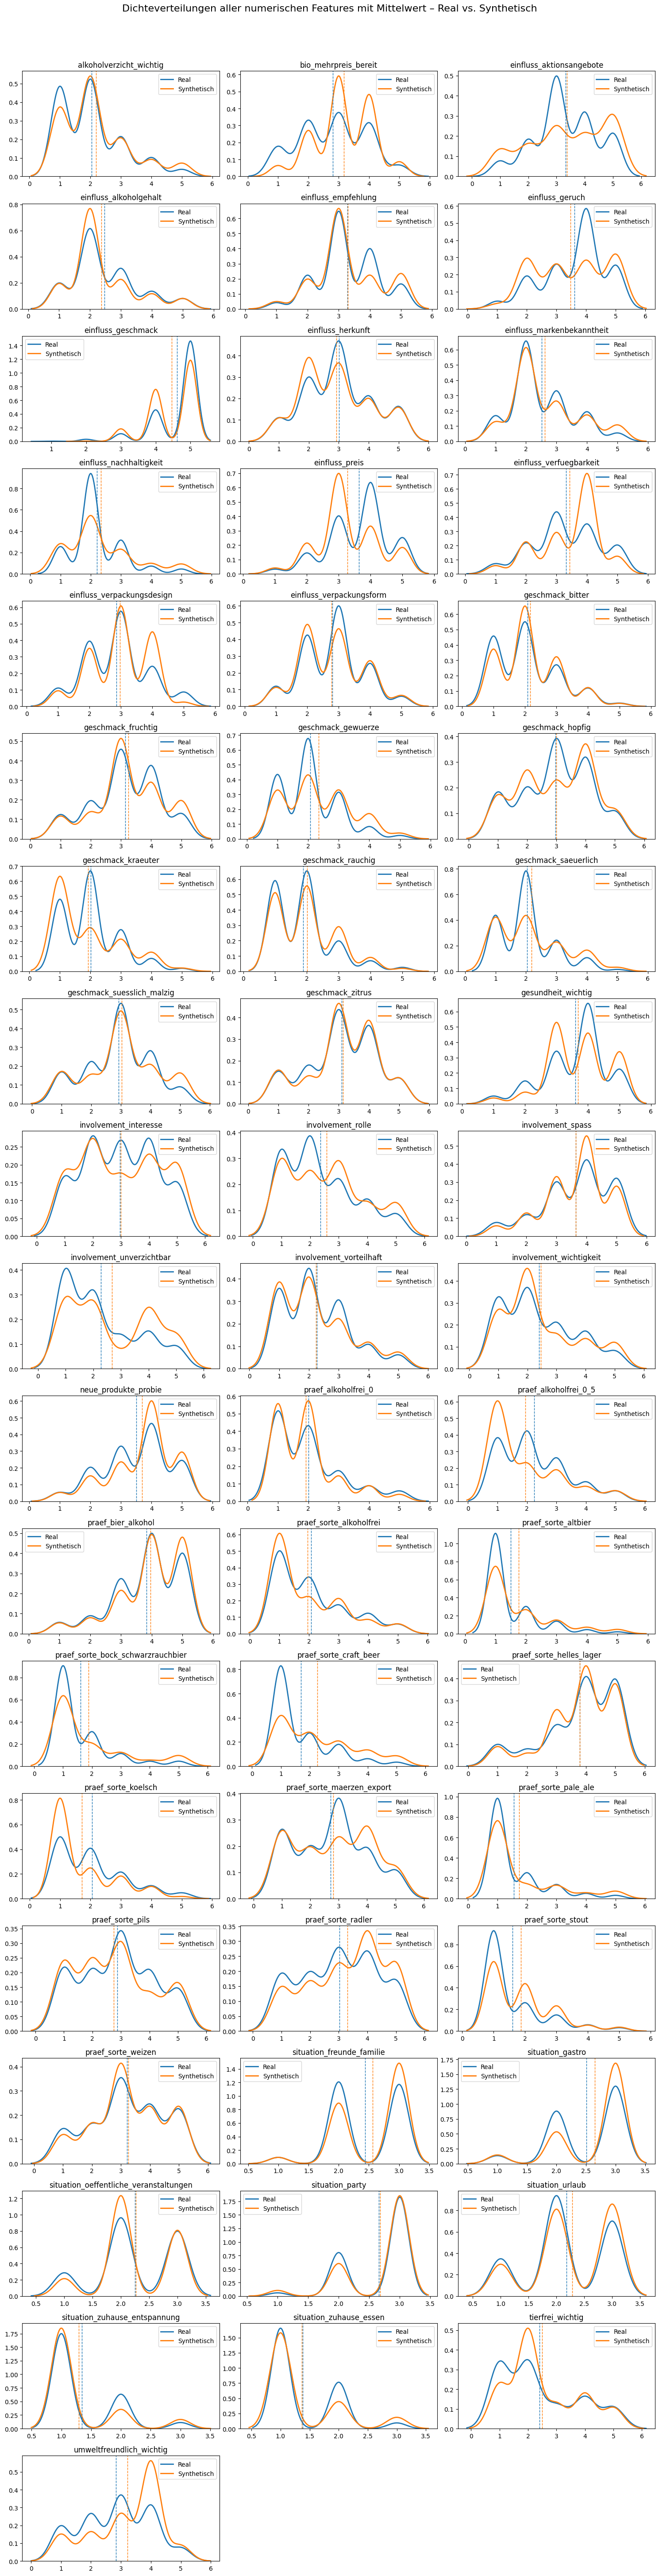

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Gemeinsame numerische Features extrahieren
df_real_num = df_real.select_dtypes(include='number')
df_syn_num = df_syn.select_dtypes(include='number')

common_cols = list(set(df_real_num.columns) & set(df_syn_num.columns))
df_real_num = df_real_num[common_cols]
df_syn_num = df_syn_num[common_cols]

# Plot-Einstellungen
n_cols = 3
n_rows = (len(common_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 3))


for i, col in enumerate(sorted(common_cols)):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # KDEs
    sns.kdeplot(df_real_num[col], label="Real", color="tab:blue", linewidth=2)
    sns.kdeplot(df_syn_num[col], label="Synthetisch", color="tab:orange", linewidth=2)
    
    # Mittelwerte
    plt.axvline(df_real_num[col].mean(), color="tab:blue", linestyle="--", linewidth=1)
    plt.axvline(df_syn_num[col].mean(), color="tab:orange", linestyle="--", linewidth=1)
    
    plt.title(col)
    plt.xlabel("")
    plt.ylabel("")
    plt.legend()

plt.tight_layout()
plt.suptitle("Dichteverteilungen aller numerischen Features mit Mittelwert – Real vs. Synthetisch", y=1.02, fontsize=16)
plt.show()


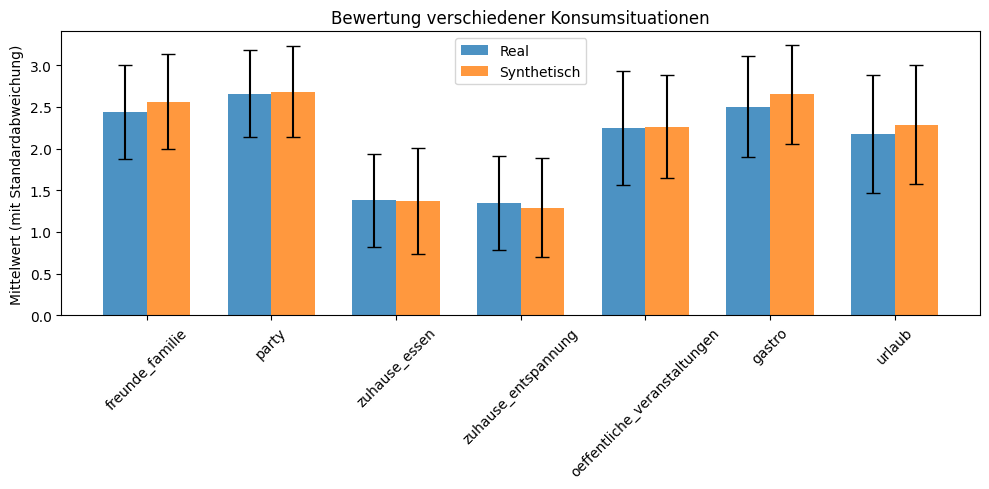

In [21]:
# Liste der "situation_"-Features
situation_features = [
    "situation_freunde_familie",
    "situation_party",
    "situation_zuhause_essen",
    "situation_zuhause_entspannung",
    "situation_oeffentliche_veranstaltungen",
    "situation_gastro",
    "situation_urlaub"
]

# Numerisch konvertieren, falls noch nicht
df_real[situation_features] = df_real[situation_features].apply(pd.to_numeric, errors='coerce')
df_syn[situation_features] = df_syn[situation_features].apply(pd.to_numeric, errors='coerce')

# Mittelwerte & Standardabweichungen berechnen
mean_real = df_real[situation_features].mean()
std_real = df_real[situation_features].std()
mean_syn = df_syn[situation_features].mean()
std_syn = df_syn[situation_features].std()

# Plot vorbereiten
x = range(len(situation_features))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=5, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=5, label='Synthetisch', alpha=0.8)

plt.xticks(x, [s.replace("situation_", "") for s in situation_features], rotation=45)
plt.ylabel("Mittelwert (mit Standardabweichung)")
plt.title("Bewertung verschiedener Konsumsituationen")
plt.legend()
plt.tight_layout()
plt.show()


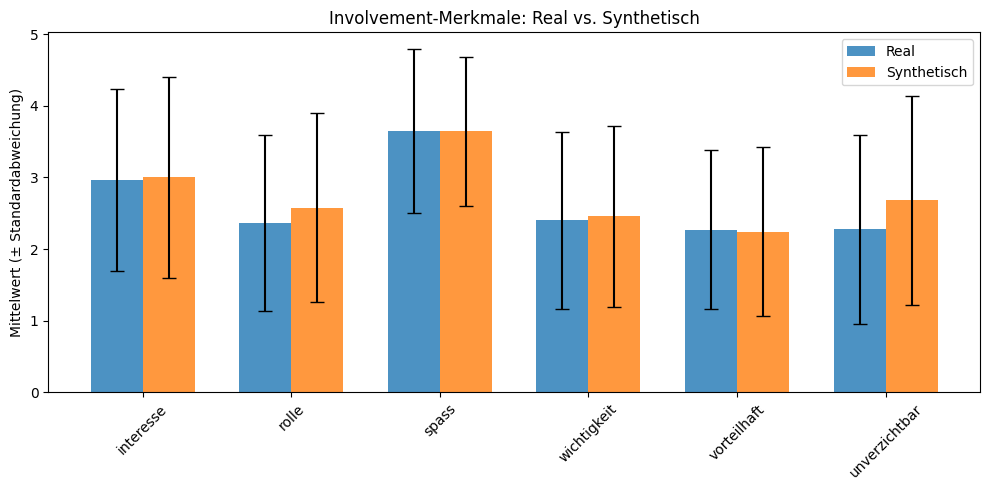

In [22]:
# Liste der 'involvement'-Features
involvement_features = [
    "involvement_interesse",
    "involvement_rolle",
    "involvement_spass",
    "involvement_wichtigkeit",
    "involvement_vorteilhaft",
    "involvement_unverzichtbar"
]

# Konvertiere zu numerisch (falls nötig)
df_real[involvement_features] = df_real[involvement_features].apply(pd.to_numeric, errors='coerce')
df_syn[involvement_features] = df_syn[involvement_features].apply(pd.to_numeric, errors='coerce')

# Mittelwerte und Standardabweichungen
mean_real = df_real[involvement_features].mean()
std_real = df_real[involvement_features].std()
mean_syn = df_syn[involvement_features].mean()
std_syn = df_syn[involvement_features].std()

# Plot erstellen
x = range(len(involvement_features))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=5, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=5, label='Synthetisch', alpha=0.8)

plt.xticks(x, [s.replace("involvement_", "") for s in involvement_features], rotation=45)
plt.ylabel("Mittelwert (± Standardabweichung)")
plt.title("Involvement-Merkmale: Real vs. Synthetisch")
plt.legend()
plt.tight_layout()
plt.show()


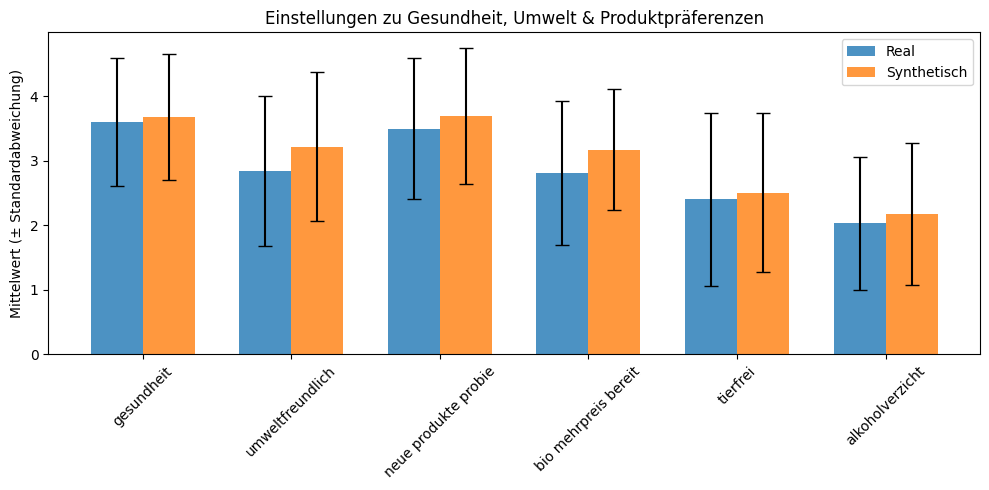

In [23]:
# Feature-Liste
bewertung_features = [
    "gesundheit_wichtig",
    "umweltfreundlich_wichtig",
    "neue_produkte_probie",
    "bio_mehrpreis_bereit",
    "tierfrei_wichtig",
    "alkoholverzicht_wichtig"
]

# Konvertiere zu numerisch (falls notwendig)
df_real[bewertung_features] = df_real[bewertung_features].apply(pd.to_numeric, errors='coerce')
df_syn[bewertung_features] = df_syn[bewertung_features].apply(pd.to_numeric, errors='coerce')

# Mittelwerte und Standardabweichungen berechnen
mean_real = df_real[bewertung_features].mean()
std_real = df_real[bewertung_features].std()
mean_syn = df_syn[bewertung_features].mean()
std_syn = df_syn[bewertung_features].std()

# Plot
x = range(len(bewertung_features))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=5, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=5, label='Synthetisch', alpha=0.8)

plt.xticks(x, [f.replace("_wichtig", "").replace("_", " ") for f in bewertung_features], rotation=45)
plt.ylabel("Mittelwert (± Standardabweichung)")
plt.title("Einstellungen zu Gesundheit, Umwelt & Produktpräferenzen")
plt.legend()
plt.tight_layout()
plt.show()


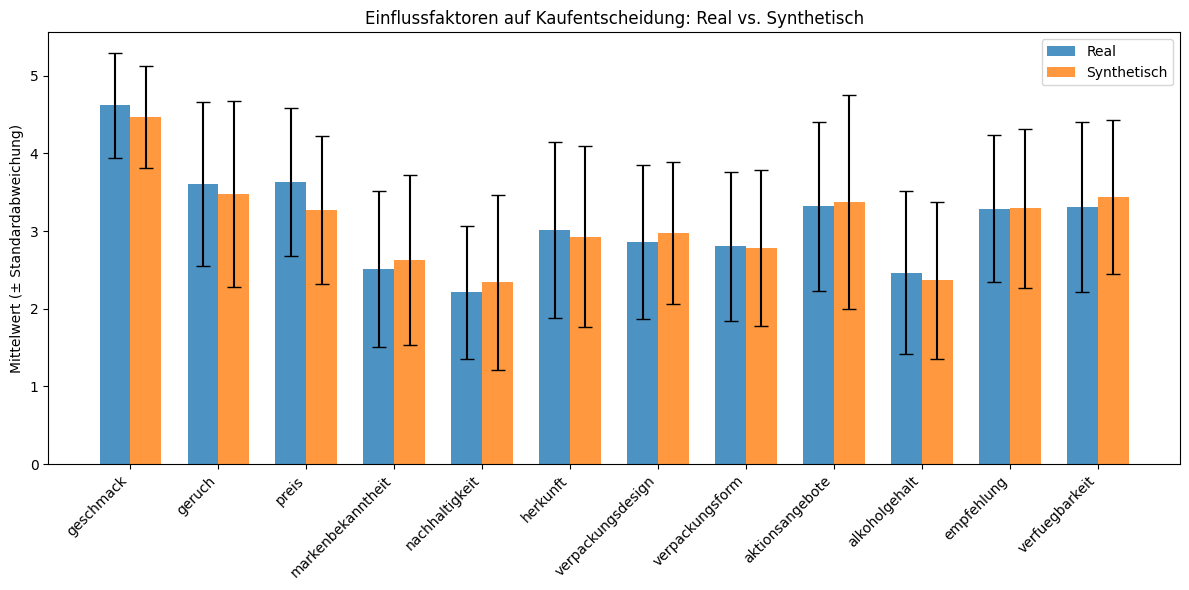

In [24]:
# Liste der Einfluss-Features
einfluss_features = [
    "einfluss_geschmack",
    "einfluss_geruch",
    "einfluss_preis",
    "einfluss_markenbekanntheit",
    "einfluss_nachhaltigkeit",
    "einfluss_herkunft",
    "einfluss_verpackungsdesign",
    "einfluss_verpackungsform",
    "einfluss_aktionsangebote",
    "einfluss_alkoholgehalt",
    "einfluss_empfehlung",
    "einfluss_verfuegbarkeit"
]

# Sicherstellen, dass alles numerisch ist
df_real[einfluss_features] = df_real[einfluss_features].apply(pd.to_numeric, errors='coerce')
df_syn[einfluss_features] = df_syn[einfluss_features].apply(pd.to_numeric, errors='coerce')

# Mittelwert & Standardabweichung
mean_real = df_real[einfluss_features].mean()
std_real = df_real[einfluss_features].std()
mean_syn = df_syn[einfluss_features].mean()
std_syn = df_syn[einfluss_features].std()

# Plot vorbereiten
x = range(len(einfluss_features))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=5, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=5, label='Synthetisch', alpha=0.8)

# Achsenbeschriftung lesbar formatieren
xtick_labels = [f.replace("einfluss_", "").replace("_", " ") for f in einfluss_features]
plt.xticks(x, xtick_labels, rotation=45, ha='right')

plt.ylabel("Mittelwert (± Standardabweichung)")
plt.title("Einflussfaktoren auf Kaufentscheidung: Real vs. Synthetisch")
plt.legend()
plt.tight_layout()
plt.show()


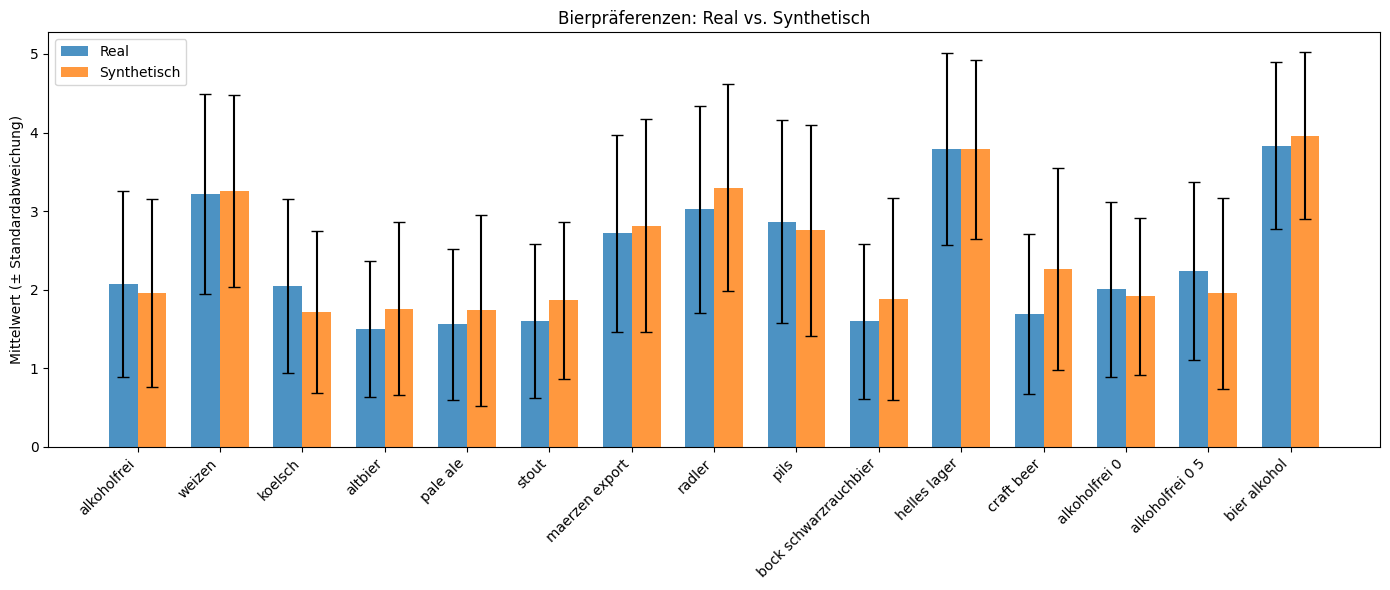

In [25]:
# Feature-Liste für Bierpräferenzen
bierpraef_features = [
    "praef_sorte_alkoholfrei",
    "praef_sorte_weizen",
    "praef_sorte_koelsch",
    "praef_sorte_altbier",
    "praef_sorte_pale_ale",
    "praef_sorte_stout",
    "praef_sorte_maerzen_export",
    "praef_sorte_radler",
    "praef_sorte_pils",
    "praef_sorte_bock_schwarzrauchbier",
    "praef_sorte_helles_lager",
    "praef_sorte_craft_beer",
    "praef_alkoholfrei_0",
    "praef_alkoholfrei_0_5",
    "praef_bier_alkohol"
]

# Sicherstellen, dass die Werte numerisch sind
df_real[bierpraef_features] = df_real[bierpraef_features].apply(pd.to_numeric, errors='coerce')
df_syn[bierpraef_features] = df_syn[bierpraef_features].apply(pd.to_numeric, errors='coerce')

# Mittelwerte und Standardabweichung berechnen
mean_real = df_real[bierpraef_features].mean()
std_real = df_real[bierpraef_features].std()
mean_syn = df_syn[bierpraef_features].mean()
std_syn = df_syn[bierpraef_features].std()

# Plot
x = range(len(bierpraef_features))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=4, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=4, label='Synthetisch', alpha=0.8)

# X-Achsenbeschriftungen formatieren
xtick_labels = [f.replace("praef_sorte_", "").replace("praef_", "").replace("_", " ") for f in bierpraef_features]
plt.xticks(x, xtick_labels, rotation=45, ha='right')

plt.ylabel("Mittelwert (± Standardabweichung)")
plt.title("Bierpräferenzen: Real vs. Synthetisch")
plt.legend()
plt.tight_layout()
plt.show()


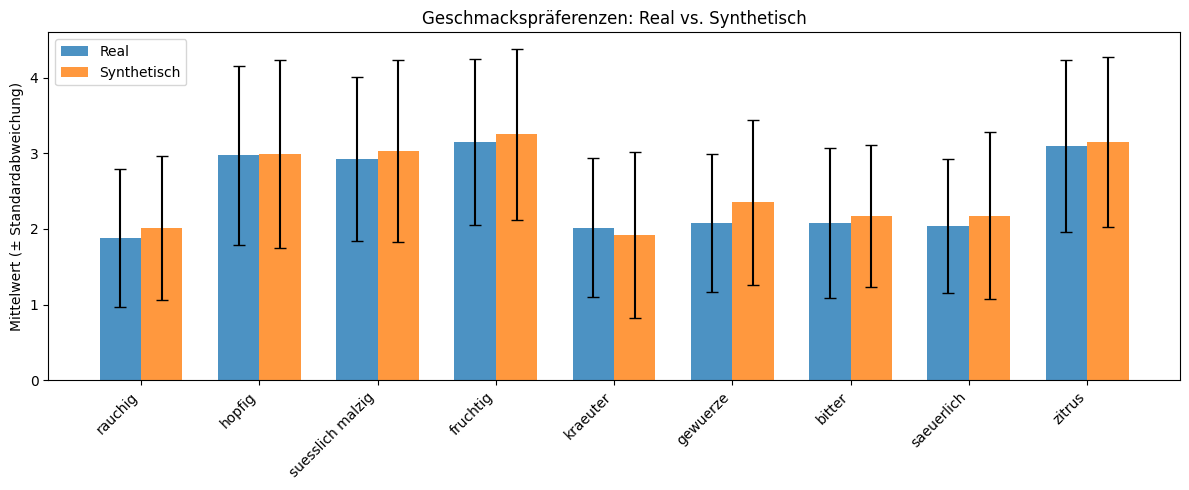

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Liste der Geschmacksmerkmale
geschmack_features = [
    "geschmack_rauchig",
    "geschmack_hopfig",
    "geschmack_suesslich_malzig",
    "geschmack_fruchtig",
    "geschmack_kraeuter",
    "geschmack_gewuerze",
    "geschmack_bitter",
    "geschmack_saeuerlich",
    "geschmack_zitrus"
]

# Numerisch sicherstellen
df_real[geschmack_features] = df_real[geschmack_features].apply(pd.to_numeric, errors='coerce')
df_syn[geschmack_features] = df_syn[geschmack_features].apply(pd.to_numeric, errors='coerce')

# Mittelwert & Standardabweichung berechnen
mean_real = df_real[geschmack_features].mean()
std_real = df_real[geschmack_features].std()
mean_syn = df_syn[geschmack_features].mean()
std_syn = df_syn[geschmack_features].std()

# Plot
x = range(len(geschmack_features))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=4, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=4, label='Synthetisch', alpha=0.8)

# Achsenbeschriftungen bereinigen
xtick_labels = [f.replace("geschmack_", "").replace("_", " ") for f in geschmack_features]
plt.xticks(x, xtick_labels, rotation=45, ha='right')

plt.ylabel("Mittelwert (± Standardabweichung)")
plt.title("Geschmackspräferenzen: Real vs. Synthetisch")
plt.legend()
plt.tight_layout()
plt.show()


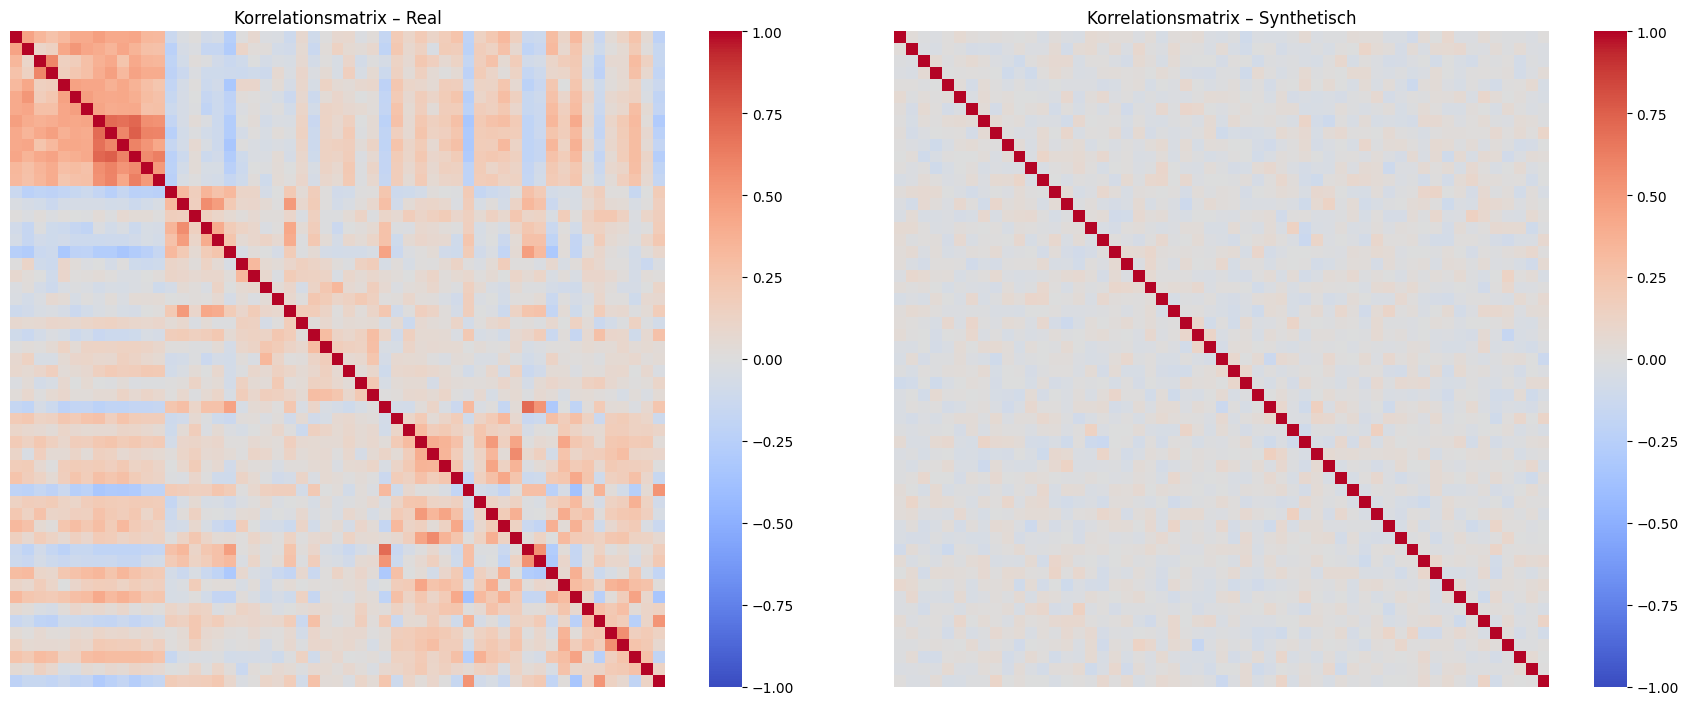

In [27]:
# Numerische Spalten automatisch auswählen
df_real_num = df_real.select_dtypes(include='number')
df_syn_num = df_syn.select_dtypes(include='number')

# Korrelationen berechnen
corr_real = df_real_num.corr()
corr_syn = df_syn_num.corr()

# Plot ohne Feature-Namen
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_real, ax=axes[0], cmap='coolwarm', center=0, vmin=-1, vmax=1, cbar=True,
            xticklabels=False, yticklabels=False, square=True)
axes[0].set_title("Korrelationsmatrix – Real")

sns.heatmap(corr_syn, ax=axes[1], cmap='coolwarm', center=0, vmin=-1, vmax=1, cbar=True,
            xticklabels=False, yticklabels=False, square=True)
axes[1].set_title("Korrelationsmatrix – Synthetisch")

plt.tight_layout()
plt.show()


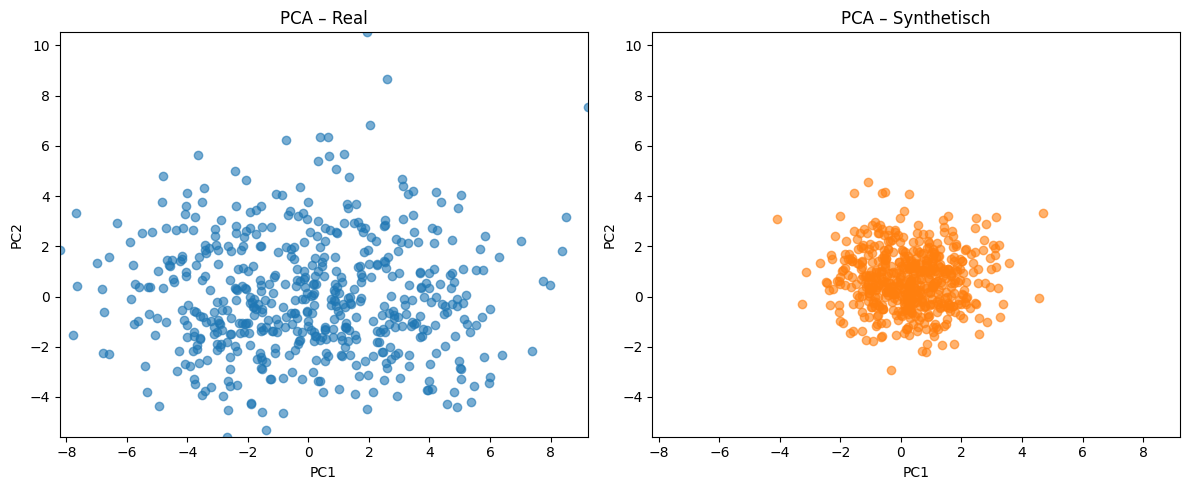

In [28]:
# Numerische Daten extrahieren und gemeinsame Spalten finden
df_real_num = df_real.select_dtypes(include='number').dropna(axis=1)
df_syn_num = df_syn.select_dtypes(include='number').dropna(axis=1)

common_cols = list(set(df_real_num.columns) & set(df_syn_num.columns))
df_real_num = df_real_num[common_cols]
df_syn_num = df_syn_num[common_cols]

# PCA: auf realen Daten fitten, beide transformieren
pca = PCA(n_components=2)
real_pca = pca.fit_transform(df_real_num)
syn_pca = pca.transform(df_syn_num)

# Visualisierung: nebeneinander
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.6, c='tab:blue')
axes[0].set_title("PCA – Real")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(syn_pca[:, 0], syn_pca[:, 1], alpha=0.6, c='tab:orange')
axes[1].set_title("PCA – Synthetisch")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

# Gleiche Achsenskalierung für beide
x_min = min(real_pca[:, 0].min(), syn_pca[:, 0].min())
x_max = max(real_pca[:, 0].max(), syn_pca[:, 0].max())
y_min = min(real_pca[:, 1].min(), syn_pca[:, 1].min())
y_max = max(real_pca[:, 1].max(), syn_pca[:, 1].max())

for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


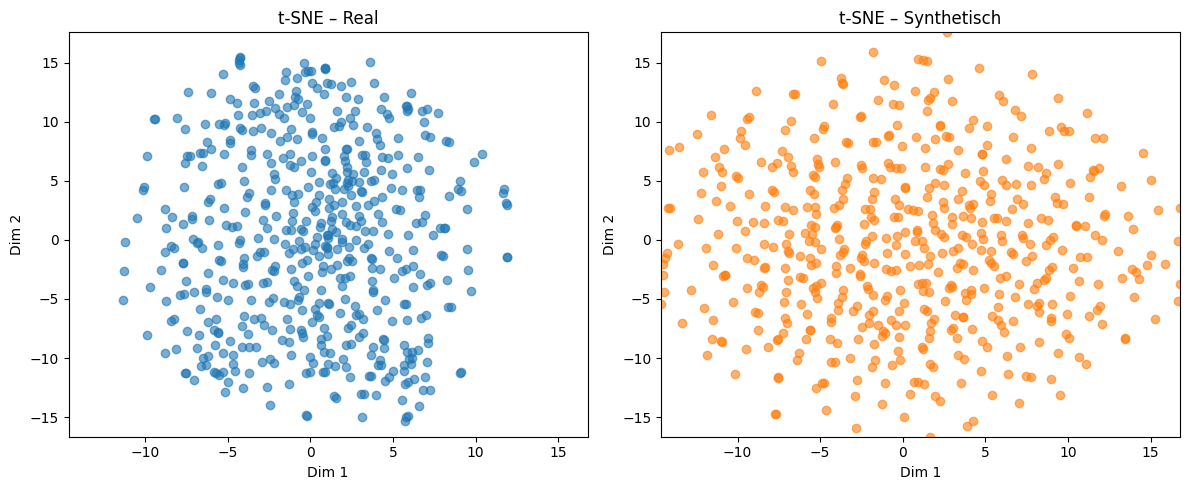

In [29]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# t-SNE für reale und synthetische Daten
tsne_real = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
real_tsne = tsne_real.fit_transform(df_real_num)

tsne_syn = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
syn_tsne = tsne_syn.fit_transform(df_syn_num)

# Gemeinsame Achsengrenzen berechnen
x_min = min(real_tsne[:, 0].min(), syn_tsne[:, 0].min())
x_max = max(real_tsne[:, 0].max(), syn_tsne[:, 0].max())
y_min = min(real_tsne[:, 1].min(), syn_tsne[:, 1].min())
y_max = max(real_tsne[:, 1].max(), syn_tsne[:, 1].max())

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(real_tsne[:, 0], real_tsne[:, 1], alpha=0.6, c='tab:blue')
axes[0].set_title("t-SNE – Real")
axes[0].set_xlabel("Dim 1")
axes[0].set_ylabel("Dim 2")
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

axes[1].scatter(syn_tsne[:, 0], syn_tsne[:, 1], alpha=0.6, c='tab:orange')
axes[1].set_title("t-SNE – Synthetisch")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


/Users/horyu72/Desktop/projekt/Bierprojekt/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


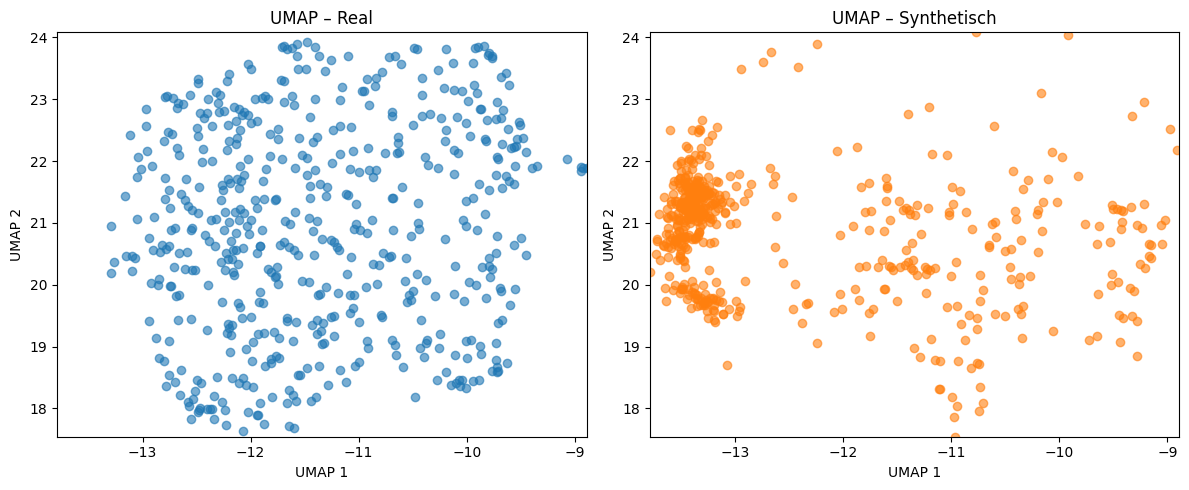

In [30]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

# UMAP auf realen Daten fitten
reducer = umap.UMAP(n_components=2, random_state=42)
real_umap = reducer.fit_transform(df_real_num)

# Synthetische Daten in denselben Raum einbetten
syn_umap = reducer.transform(df_syn_num)

# Gemeinsame Achsengrenzen berechnen
x_min = min(real_umap[:, 0].min(), syn_umap[:, 0].min())
x_max = max(real_umap[:, 0].max(), syn_umap[:, 0].max())
y_min = min(real_umap[:, 1].min(), syn_umap[:, 1].min())
y_max = max(real_umap[:, 1].max(), syn_umap[:, 1].max())

# Visualisierung nebeneinander
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(real_umap[:, 0], real_umap[:, 1], alpha=0.6, c='tab:blue')
axes[0].set_title("UMAP – Real")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

axes[1].scatter(syn_umap[:, 0], syn_umap[:, 1], alpha=0.6, c='tab:orange')
axes[1].set_title("UMAP – Synthetisch")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, AgglomerativeClustering

def plot_clusters_consistent(data_real, data_syn, clusters_real, clusters_syn, title, method_name):
    palette = sns.color_palette("tab10", np.unique(clusters_real).shape[0])
    color_map = {label: palette[i % len(palette)] for i, label in enumerate(np.unique(clusters_real))}
    
    colors_real = [color_map[label] for label in clusters_real]
    colors_syn = [color_map.get(label, (0.6, 0.6, 0.6)) for label in clusters_syn]

    x_min = min(data_real[:, 0].min(), data_syn[:, 0].min())
    x_max = max(data_real[:, 0].max(), data_syn[:, 0].max())
    y_min = min(data_real[:, 1].min(), data_syn[:, 1].min())
    y_max = max(data_real[:, 1].max(), data_syn[:, 1].max())

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(data_real[:, 0], data_real[:, 1], c=colors_real, alpha=0.7)
    axes[0].set_title(f"{method_name} – {title} (Real)")

    axes[1].scatter(data_syn[:, 0], data_syn[:, 1], c=colors_syn, alpha=0.7)
    axes[1].set_title(f"{method_name} – {title} (Synthetisch)")

    for ax in axes:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")

    plt.tight_layout()
    plt.show()


| Beobachtung                            | Bedeutung                                                                                                              |
| -------------------------------------- | ---------------------------------------------------------------------------------------------------------------------- |
| **Clusterverteilung ähnlich**          | Strukturierte Merkmalsbeziehungen (Abstände, Gruppen) wurden im synthetischen Datensatz teilweise **gut nachgebildet** |
| **t-SNE/UMAP unterschiedlich**         | Die **feinkörnige Topologie** (z. B. lokale Dichte) oder **nichtlineare Beziehungen** unterscheiden sich               |
| **PCA wirkt „gequetscht“**             | Die **Varianz** in den synthetischen Daten ist geringer – die Daten sind oft „zentriert“                               |
| **Cluster überlappen visuell weniger** | Das kann an **glatteren, künstlicheren Clustern** im synthetischen Set liegen – oder daran, dass Extremwerte fehlen    |


Dein Generator reproduziert gut die grobe Struktur der Daten (Cluster), aber nicht notwendigerweise deren Streuung, Dichte und nichtlineare Zusammenhänge.
Das ist für viele Anwendungen ausreichend gut – z. B. bei Training von Modellen, die robuste Cluster erkennen sollen.
Für feinere statistische Analysen wäre es evtl. noch nicht realistisch genug.

Das ist für viele Anwendungen ausreichend gut – z. B. bei Training von Modellen, die robuste Cluster erkennen sollen.
Für feinere statistische Analysen wäre es evtl. noch nicht realistisch genug.

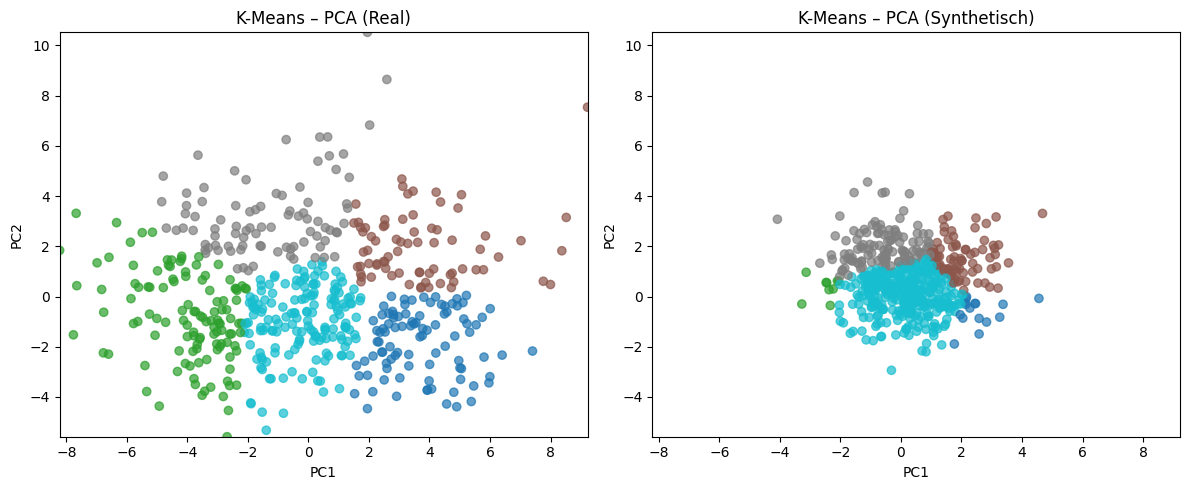

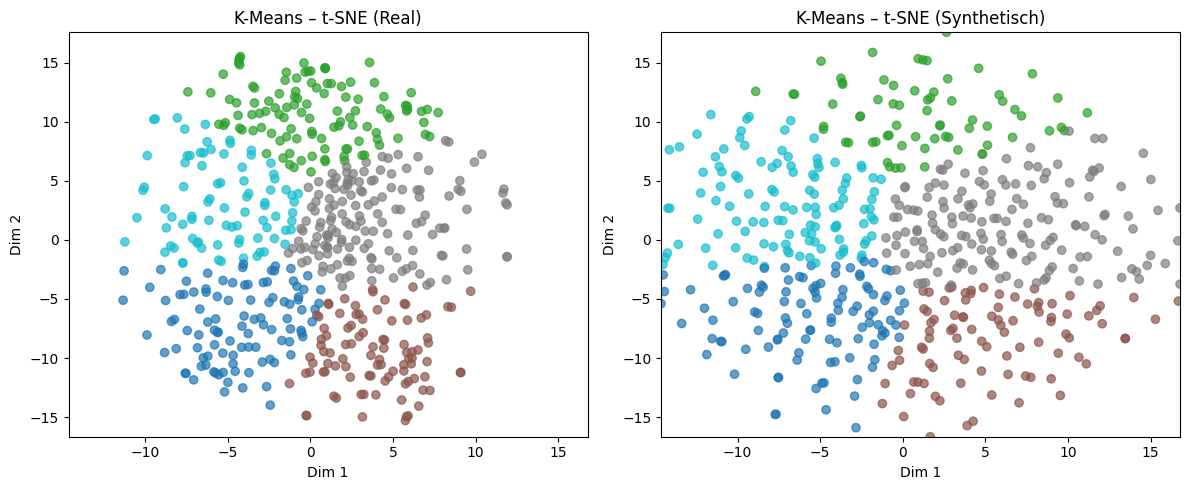

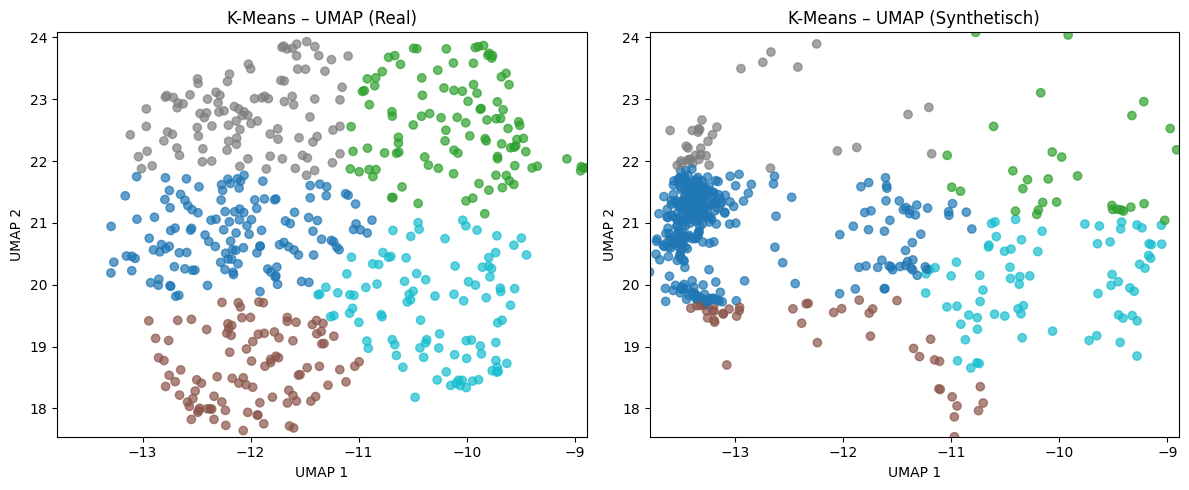

Silhouette Score (PCA – Real):         0.3290867342153899
Silhouette Score (PCA – Synthetisch):  0.20785390615207108
Silhouette Score (t-SNE – Real):       0.360551118850708
Silhouette Score (t-SNE – Synthetisch): 0.3097342252731323
Silhouette Score (UMAP – Real):        0.419543981552124
Silhouette Score (UMAP – Synthetisch): 0.29151421785354614


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Anzahl der Cluster
n_clusters = 5

# --- PCA-Clustering ---
kmeans_pca = KMeans(n_clusters=n_clusters, random_state=42)
clusters_real_pca = kmeans_pca.fit_predict(real_pca)
clusters_syn_pca = kmeans_pca.predict(syn_pca)

# Achsenskalen (PCA)
x_min_pca = min(real_pca[:, 0].min(), syn_pca[:, 0].min())
x_max_pca = max(real_pca[:, 0].max(), syn_pca[:, 0].max())
y_min_pca = min(real_pca[:, 1].min(), syn_pca[:, 1].min())
y_max_pca = max(real_pca[:, 1].max(), syn_pca[:, 1].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(real_pca[:, 0], real_pca[:, 1], c=clusters_real_pca, cmap='tab10', alpha=0.7)
axes[0].set_title("K-Means – PCA (Real)")
axes[0].set_xlim(x_min_pca, x_max_pca)
axes[0].set_ylim(y_min_pca, y_max_pca)

axes[1].scatter(syn_pca[:, 0], syn_pca[:, 1], c=clusters_syn_pca, cmap='tab10', alpha=0.7)
axes[1].set_title("K-Means – PCA (Synthetisch)")
axes[1].set_xlim(x_min_pca, x_max_pca)
axes[1].set_ylim(y_min_pca, y_max_pca)

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()


# --- t-SNE-Clustering ---
kmeans_tsne = KMeans(n_clusters=n_clusters, random_state=42)
clusters_real_tsne = kmeans_tsne.fit_predict(real_tsne)
clusters_syn_tsne = kmeans_tsne.predict(syn_tsne)

x_min_tsne = min(real_tsne[:, 0].min(), syn_tsne[:, 0].min())
x_max_tsne = max(real_tsne[:, 0].max(), syn_tsne[:, 0].max())
y_min_tsne = min(real_tsne[:, 1].min(), syn_tsne[:, 1].min())
y_max_tsne = max(real_tsne[:, 1].max(), syn_tsne[:, 1].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(real_tsne[:, 0], real_tsne[:, 1], c=clusters_real_tsne, cmap='tab10', alpha=0.7)
axes[0].set_title("K-Means – t-SNE (Real)")
axes[0].set_xlim(x_min_tsne, x_max_tsne)
axes[0].set_ylim(y_min_tsne, y_max_tsne)

axes[1].scatter(syn_tsne[:, 0], syn_tsne[:, 1], c=clusters_syn_tsne, cmap='tab10', alpha=0.7)
axes[1].set_title("K-Means – t-SNE (Synthetisch)")
axes[1].set_xlim(x_min_tsne, x_max_tsne)
axes[1].set_ylim(y_min_tsne, y_max_tsne)

for ax in axes:
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(real_umap[:, 0], real_umap[:, 1], c=clusters_real_umap, cmap='tab10', alpha=0.7)
axes[0].set_title("K-Means – UMAP (Real)")
axes[0].set_xlim(x_min_umap, x_max_umap)
axes[0].set_ylim(y_min_umap, y_max_umap)

axes[1].scatter(syn_umap[:, 0], syn_umap[:, 1], c=clusters_syn_umap, cmap='tab10', alpha=0.7)
axes[1].set_title("K-Means – UMAP (Synthetisch)")
axes[1].set_xlim(x_min_umap, x_max_umap)
axes[1].set_ylim(y_min_umap, y_max_umap)

for ax in axes:
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()


# --- Optional: Clustering-Qualität bewerten (Silhouette) ---
print("Silhouette Score (PCA – Real):        ", silhouette_score(real_pca, clusters_real_pca))
print("Silhouette Score (PCA – Synthetisch): ", silhouette_score(syn_pca, clusters_syn_pca))
print("Silhouette Score (t-SNE – Real):      ", silhouette_score(real_tsne, clusters_real_tsne))
print("Silhouette Score (t-SNE – Synthetisch):", silhouette_score(syn_tsne, clusters_syn_tsne))


In [33]:
""" import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, AgglomerativeClustering

def plot_clusters_consistent(data_real, data_syn, clusters_real, clusters_syn, title, method_name):
    palette = sns.color_palette("tab10", np.unique(clusters_real).shape[0])
    color_map = {label: palette[i % len(palette)] for i, label in enumerate(np.unique(clusters_real))}
    
    colors_real = [color_map[label] for label in clusters_real]
    colors_syn = [color_map.get(label, (0.6, 0.6, 0.6)) for label in clusters_syn]

    x_min = min(data_real[:, 0].min(), data_syn[:, 0].min())
    x_max = max(data_real[:, 0].max(), data_syn[:, 0].max())
    y_min = min(data_real[:, 1].min(), data_syn[:, 1].min())
    y_max = max(data_real[:, 1].max(), data_syn[:, 1].max())

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(data_real[:, 0], data_real[:, 1], c=colors_real, alpha=0.7)
    axes[0].set_title(f"{method_name} – {title} (Real)")

    axes[1].scatter(data_syn[:, 0], data_syn[:, 1], c=colors_syn, alpha=0.7)
    axes[1].set_title(f"{method_name} – {title} (Synthetisch)")

    for ax in axes:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")

    plt.tight_layout()
    plt.show()

def agglomerative_with_consistent_colors(data_real, data_syn, title, n_clusters=5):
    model = AgglomerativeClustering(n_clusters=n_clusters)
    clusters_real = model.fit_predict(data_real)
    clusters_syn = model.fit_predict(data_syn)  # kein .predict(), daher separat

    plot_clusters_consistent(data_real, data_syn, clusters_real, clusters_syn, title, "Agglomerativ")

def dbscan_with_consistent_colors(data_real, data_syn, title, eps=1.5, min_samples=5):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    clusters_real = model.fit_predict(data_real)
    clusters_syn = model.fit_predict(data_syn)

    plot_clusters_consistent(data_real, data_syn, clusters_real, clusters_syn, title, "DBSCAN")



# PCA
agglomerative_with_consistent_colors(real_pca, syn_pca, "PCA", n_clusters=5)
dbscan_with_consistent_colors(real_pca, syn_pca, "PCA", eps=1.5)

# t-SNE
agglomerative_with_consistent_colors(real_tsne, syn_tsne, "t-SNE", n_clusters=5)
dbscan_with_consistent_colors(real_tsne, syn_tsne, "t-SNE", eps=3)

# UMAP
agglomerative_with_consistent_colors(real_umap, syn_umap, "UMAP", n_clusters=5)
dbscan_with_consistent_colors(real_umap, syn_umap, "UMAP", eps=1.2)
 """

' import numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom sklearn.cluster import DBSCAN, AgglomerativeClustering\n\ndef plot_clusters_consistent(data_real, data_syn, clusters_real, clusters_syn, title, method_name):\n    palette = sns.color_palette("tab10", np.unique(clusters_real).shape[0])\n    color_map = {label: palette[i % len(palette)] for i, label in enumerate(np.unique(clusters_real))}\n\n    colors_real = [color_map[label] for label in clusters_real]\n    colors_syn = [color_map.get(label, (0.6, 0.6, 0.6)) for label in clusters_syn]\n\n    x_min = min(data_real[:, 0].min(), data_syn[:, 0].min())\n    x_max = max(data_real[:, 0].max(), data_syn[:, 0].max())\n    y_min = min(data_real[:, 1].min(), data_syn[:, 1].min())\n    y_max = max(data_real[:, 1].max(), data_syn[:, 1].max())\n\n    fig, axes = plt.subplots(1, 2, figsize=(12, 5))\n    axes[0].scatter(data_real[:, 0], data_real[:, 1], c=colors_real, alpha=0.7)\n    axes[0].set_title(f"{method_name} – 